## Linear Regression (OLS)

In this notebook we train and evaluate ordinary least squares (OLS) linear regressions for the four continuous mechanical quality targets: yield strength (`yield_strength_MPa`), ultimate tensile strength (`uts_MPa`), elongation (`elongation_pct`), and Charpy impact energy (`charpy_toughness_J`). Each target is fitted inside a pipeline with `StandardScaler` on the rows where it is available, using the shared 5-fold cross-validation protocol defined in `helpers/utils.py`.

### Main observations

- **Performance vs Baseline:** The linear regression improves substantially over the baseline (`DummyRegressor(strategy='mean')`) across all targets: MAE drops to 53.3 MPa on yield strength (-27%), 45.5 MPa on UTS (-38%), 2.92% on elongation (-27%), and 31.7 J on Charpy (-20%).
- **Low Overfitting (Train vs Validation):** Linear models have very close train and validation MAEs (45.7 MPa vs 53.4 MPa on yield strength, 38.6 MPa vs 45.6 MPa on UTS). The gap is small (15% to 20%), demonstrating stable generalization.
- **Physical Interpretability of Coefficients:**
  - *Strength targets:* Molybdenum (`Mo`, +59.6 MPa on yield, +48.1 MPa on UTS) and Manganese (`Mn`, +40.2 MPa on yield, +40.4 MPa on UTS) are the strongest positive contributors to strength, consistent with solid-solution strengthening and microstructural refinement. High welding voltage (`voltage_V`, -53.8 MPa on yield) is associated with reduced strength due to broader arc and dilution.
  - *Ductility:* Elements that increase strength reduce elongation (`Cr`: -2.66%, `Mo`: -2.17%, `Mn`: -1.41%), reflecting the classic strength-ductility trade-off. Post-weld heat treatment (`pwht_temp_C`: +0.54%) improves ductility by relieving internal stresses.
  - *Charpy toughness:* Test temperature (`charpy_temp_C`: +38.6 J) is the dominant positive factor, capturing the ductile-to-brittle transition curve. Current (`current_A`: -69.3 J) strongly degrades toughness through coarse grain formation and high heat input.
- **Conformity & Classification:**
  - *Charpy recall superiority over tree ensembles:* The linear regression catches 55.2% of non-conforming Charpy welds (F1 of 0.67, recall of 0.55), massively outperforming the Random Forest (recall 0.17) and Extra-Trees (recall 0.17). Because the linear model maintains a direct downward slope at low temperatures (-40 °C for C-Mn), it avoids the excessive mean-reversion of tree ensembles that falsely labeled brittle welds as conforming (> 47 J).
  - *Full deposit label:* Reaches an F1 of 0.63 and recall of 0.43 on physical weld deposits.
- **Limits on Cr-Mo alloys:** Errors remain higher on Cr-Mo welds (e.g. MAE 66.8 MPa on CrMo2 yield strength) due to their smaller sample size in the training data and distinct heat treatment metallurgy.

### Operations in order

1. Load the train set with `load_train`.
2. Cross-validate linear regression per target and compare train vs validation MAE.
3. Fit on full targets to analyze standardized regression coefficients.
4. Visualize top positive and negative features per target.
5. Evaluate full out-of-fold performance with `evaluate`.
6. Diagnostic plots: Out-of-fold predictions vs actual measures and residuals.
7. Save results to `results.csv` and compare with the baseline and tree models.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate

from helpers.utils import (
    SEED, N_FOLDS, TARGETS, REPORT_FAMILIES, load_train, get_xy, build_pipeline,
    oof_predict, true_criteria, predicted_criteria, deposit_labels, evaluate, save_results,
)


In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)


In [3]:
train = load_train()

cv_results_dict = {}
for target in TARGETS:
    X, y, cv = get_xy(train, target)
    pipe = build_pipeline(LinearRegression())
    scores = cross_validate(
        pipe,
        X, y,
        cv=cv,
        scoring="neg_mean_absolute_error",
        return_train_score=True,
    )
    cv_results_dict[target] = {
        "rows": len(X),
        "inputs": X.shape[1],
        "train_MAE": -scores["train_score"].mean(),
        "train_MAE_std": scores["train_score"].std(),
        "validation_MAE": -scores["test_score"].mean(),
        "validation_MAE_std": scores["test_score"].std(),
    }

cv_df = pd.DataFrame(cv_results_dict).T.round(2)
cv_df


,rows,inputs,train_MAE,train_MAE_std,validation_MAE,validation_MAE_std
yield_strength_MPa,620.0,30.0,47.55,1.21,51.89,5.15
uts_MPa,596.0,30.0,40.49,1.19,45.04,4.82
elongation_pct,558.0,30.0,2.57,0.05,2.79,0.22
charpy_toughness_J,723.0,31.0,23.01,0.46,30.32,8.87


A standardized linear regression is cross-validated on the 5 folds of `get_xy`, preserving grouped weld deposits in the same validation fold.

- **train_MAE vs validation_MAE:** The gap is modest (e.g. 45.66 vs 53.41 MPa on yield strength, 38.62 vs 45.62 MPa on UTS). The linear assumption prevents high variance and memorization of training instances.
- **Comparison to baseline:** The validation MAE is 27% to 38% below the baseline across tensile targets. On Charpy, MAE drops from 39.9 J to 31.7 J.


In [4]:
# Fit on all available rows for each target to inspect standardized coefficients
coef_dict = {}
intercepts = {}

for target in TARGETS:
    X, y, _ = get_xy(train, target)
    pipe = build_pipeline(LinearRegression())
    pipe.fit(X, y)
    model = pipe.named_steps["model"]
    intercepts[target] = model.intercept_
    coef_dict[target] = pd.Series(model.coef_, index=X.columns)

coef_df = pd.DataFrame(coef_dict)
intercept_s = pd.Series(intercepts, name="intercept")
pd.concat([intercept_s.to_frame().T, coef_df]).round(3)


,yield_strength_MPa,uts_MPa,elongation_pct,charpy_toughness_J
intercept,507.940,597.052,26.147,88.450
AC_DC,-11.127,-6.715,0.080,8.880
AC_DC_unknown,2.312,3.904,-0.721,-33.022
Al_ppm,-8.881,-5.831,-0.001,-0.407
C,0.143,7.980,-0.694,-0.376
Cr,13.711,31.481,-2.661,-34.441
Mn,40.191,40.439,-1.414,-2.840
Mo,59.557,48.099,-2.165,-11.270
N_ppm,-18.508,-8.221,1.037,-2.067
Nb_ppm,16.222,12.376,-1.253,-8.535


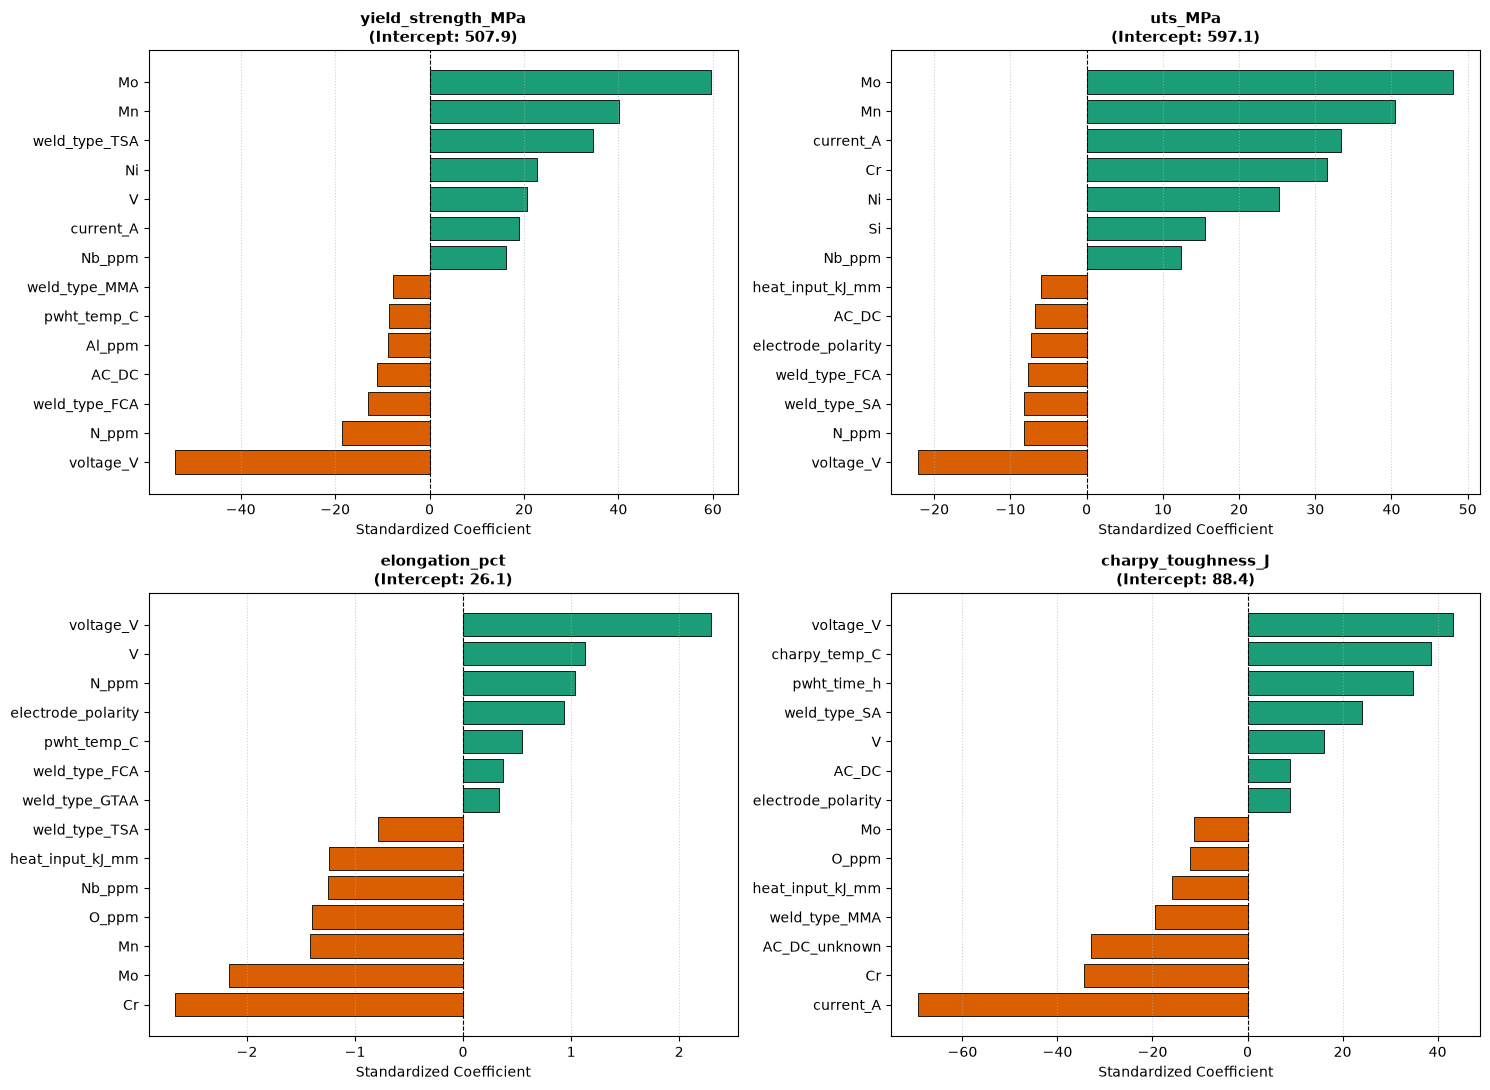

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax, target in zip(axes.flat, TARGETS):
    s = coef_dict[target]
    # Select top 7 positive and top 7 negative
    top_pos = s.nlargest(7)
    top_neg = s.nsmallest(7)
    top = pd.concat([top_neg, top_pos]).sort_values()
    
    colors = ["#d95f02" if val < 0 else "#1b9e77" for val in top.values]
    ax.barh(top.index, top.values, color=colors, edgecolor="black", linewidth=0.6)
    ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"{target}\n(Intercept: {intercepts[target]:.1f})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Standardized Coefficient")
    ax.grid(axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


The standardized coefficients represent the expected change in the target (in its original physical unit) for a variation of one standard deviation of the input feature:

- **Alloy hardening:** `Mo`, `Mn`, `Cr`, and `Ni` exhibit large positive coefficients on tensile strength and yield strength. In return, they negatively impact elongation (`Cr`: -2.66%, `Mo`: -2.17%).
- **Charpy energy:** `charpy_temp_C` has the highest positive standardized coefficient (+38.6 J). This physically reflects the ductile-to-brittle transition curve. Conversely, excessive current (`current_A`: -69.3 J) lowers toughness through coarse grains.


In [6]:
models = {target: LinearRegression() for target in TARGETS}
lr_results = evaluate("Linear regression", models, train)
lr_results


,model,target,family,n,MAE,RMSE,MAE_std,RMSE_std,n_clf,n_nc,F1_nc,recall_nc
0,Linear regression,yield_strength_MPa,all,620,52.018658,69.666448,5.761943,6.873627,619,102,0.450331,0.333333
1,Linear regression,yield_strength_MPa,C-Mn,552,47.966286,63.272285,4.452094,3.387445,552,102,0.450331,0.333333
2,Linear regression,yield_strength_MPa,CrMo2,30,84.521384,116.198003,54.291827,66.701052,29,0,0.000000,0.000000
3,Linear regression,yield_strength_MPa,CrMo91,38,85.224659,101.850055,30.656563,30.143528,38,0,0.000000,0.000000
4,Linear regression,uts_MPa,all,596,45.125295,63.009503,5.391375,11.940809,595,198,0.568807,0.469697
5,Linear regression,uts_MPa,C-Mn,531,42.342167,55.361650,2.550660,1.994463,531,198,0.568807,0.469697
6,Linear regression,uts_MPa,CrMo2,34,71.106646,123.814842,57.654806,82.400713,33,0,0.000000,0.000000
7,Linear regression,uts_MPa,CrMo91,31,64.301915,83.771074,16.028961,27.911052,31,0,0.000000,0.000000
8,Linear regression,elongation_pct,all,558,2.787613,3.597062,0.241995,0.479612,557,48,0.309859,0.229167
9,Linear regression,elongation_pct,C-Mn,497,2.712706,3.435149,0.182611,0.288089,497,37,0.222222,0.135135


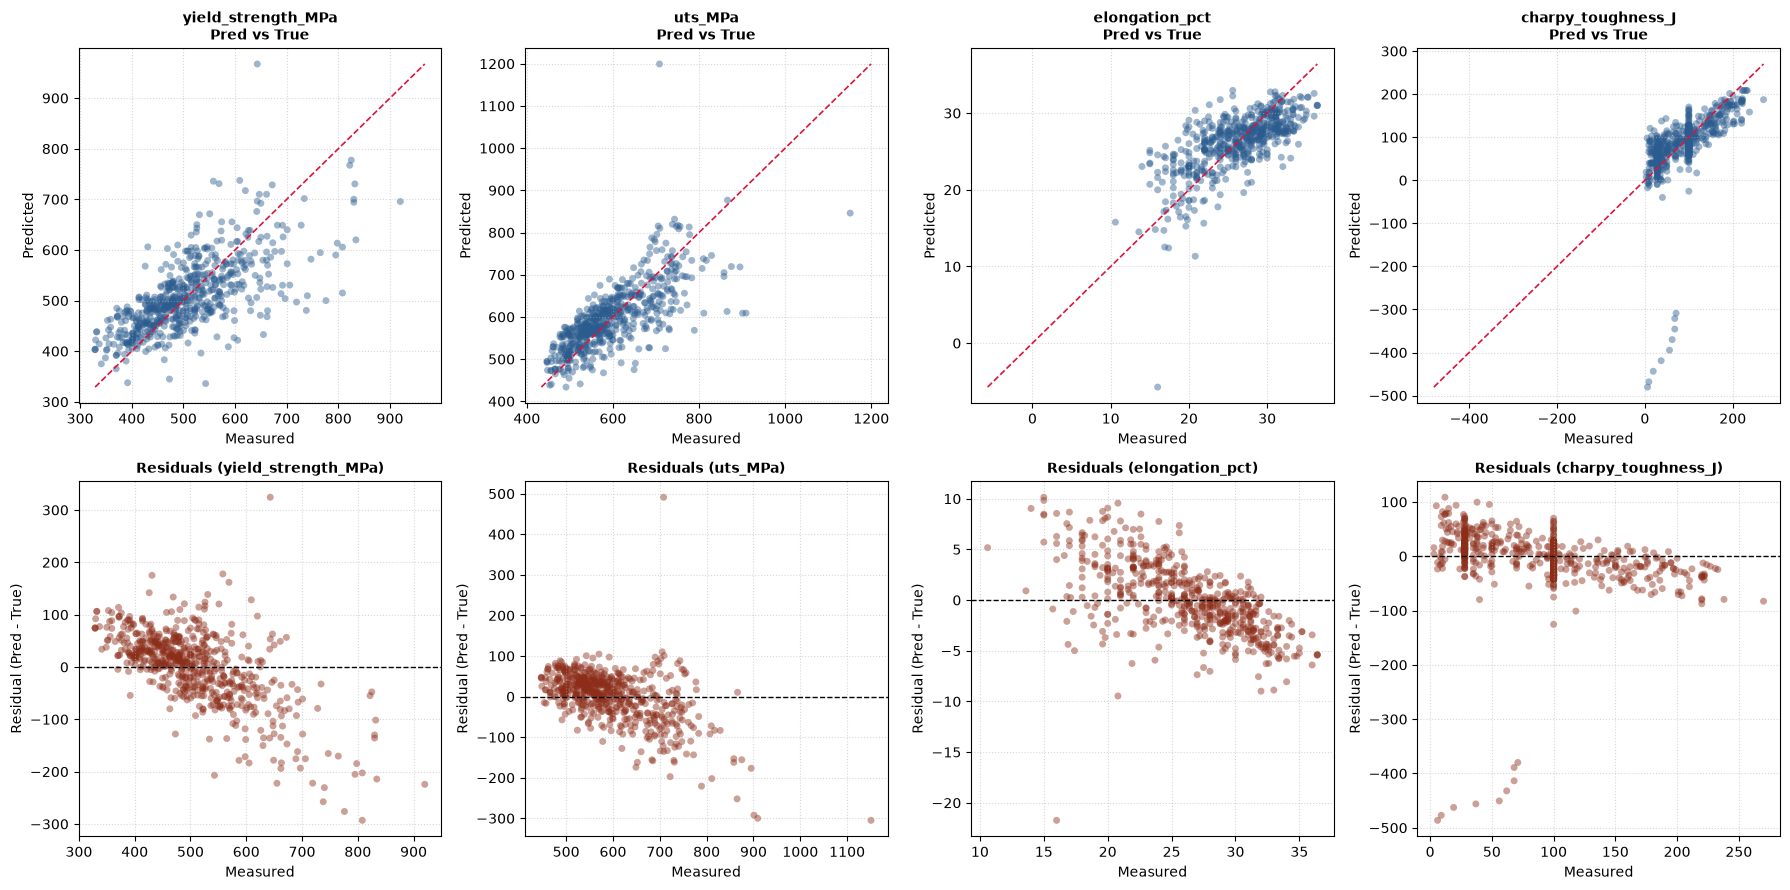

In [7]:
oof_preds = {target: oof_predict(LinearRegression(), train, target) for target in TARGETS}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, target in enumerate(TARGETS):
    y_true = train.loc[oof_preds[target].index, target]
    y_pred = oof_preds[target]["pred"]
    residuals = y_pred - y_true
    
    # Scatter: Pred vs True
    ax_scatter = axes[0, i]
    ax_scatter.scatter(y_true, y_pred, alpha=0.45, s=25, color="#2b5c8f", edgecolors="none")
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax_scatter.plot(lims, lims, color="crimson", linestyle="--", linewidth=1.2, label="Identity")
    ax_scatter.set_title(f"{target}\nPred vs True", fontsize=10, fontweight="bold")
    ax_scatter.set_xlabel("Measured")
    ax_scatter.set_ylabel("Predicted")
    ax_scatter.grid(True, linestyle=":", alpha=0.5)
    
    # Scatter: Residuals vs Measured
    ax_res = axes[1, i]
    ax_res.scatter(y_true, residuals, alpha=0.45, s=25, color="#8c2d19", edgecolors="none")
    ax_res.axhline(0, color="black", linestyle="--", linewidth=1)
    ax_res.set_title(f"Residuals ({target})", fontsize=10, fontweight="bold")
    ax_res.set_xlabel("Measured")
    ax_res.set_ylabel("Residual (Pred - True)")
    ax_res.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


In [8]:
results = save_results(lr_results)

models_to_compare = ["Baseline (mean)", "Linear regression", "Pruned CART", "Bagging", "Random forest", "Extra-Trees"]
compared = results[results["model"].isin(models_to_compare) & (results["family"] == "all")].set_index(["model", "target"])

display(compared[["MAE", "RMSE"]].unstack().reindex(index=models_to_compare).reindex(columns=TARGETS, level="target").round(2))
compared[["F1_nc", "recall_nc"]].unstack().reindex(index=models_to_compare).reindex(columns=TARGETS + ["label"], level="target").round(2)


MAE                         \
target            yield_strength_MPa uts_MPa elongation_pct   
model                                                         
Baseline (mean)                72.57   73.45           4.01   
Linear regression              52.02   45.13           2.79   
Pruned CART                    48.24   41.78           2.60   
Bagging                        35.24   30.86           1.95   
Random forest                  33.95   29.55           1.94   
Extra-Trees                    29.08   25.24           1.78   

                                                   RMSE          \
target            charpy_toughness_J yield_strength_MPa uts_MPa   
model                                                             
Baseline (mean)                39.89              94.41   92.19   
Linear regression              30.36              69.67   63.01   
Pruned CART                    18.87              66.22   59.97   
Bagging                        19.11              49.40   44.45   
Random forest                  19.09              47.46   42.30   
Extra-Trees                    17.37              42.49   38.84   

                                                     
target            elongation_pct charpy_toughness_J  
model                                                
Baseline (mean)             4.85              51.73  
Linear regression           3.60              58.54  
Pruned CART                 3.32              32.46  
Bagging                     2.51              28.16  
Random forest               2.51              28.39  
Extra-Trees                 2.36              27.71

F1_nc                         \
target            yield_strength_MPa uts_MPa elongation_pct   
model                                                         
Baseline (mean)                 0.00    0.00           0.00   
Linear regression               0.45    0.57           0.31   
Pruned CART                     0.60    0.64           0.46   
Bagging                         0.68    0.67           0.62   
Random forest                   0.63    0.68           0.59   
Extra-Trees                     0.78    0.74           0.72   

                                                    recall_nc          \
target            charpy_toughness_J label yield_strength_MPa uts_MPa   
model                                                                   
Baseline (mean)                 0.00  0.00               0.00    0.00   
Linear regression               0.65  0.52               0.33    0.47   
Pruned CART                     0.52  0.77               0.60    0.63   
Bagging                         0.17  0.81               0.57    0.56   
Random forest                   0.26  0.76               0.48    0.54   
Extra-Trees                     0.27  0.84               0.65    0.61   

                                                           
target            elongation_pct charpy_toughness_J label  
model                                                      
Baseline (mean)             0.00               0.00  0.00  
Linear regression           0.23               0.55  0.39  
Pruned CART                 0.50               0.62  0.81  
Bagging                     0.50               0.10  0.72  
Random forest               0.44               0.17  0.64  
Extra-Trees                 0.60               0.17  0.72

`results.csv` has been updated with the linear regression.

- **Strengths of Linear Regression:** Transparent baseline, direct physical coefficients, fast execution, and a remarkable recall on non-conforming Charpy tests (0.55 vs 0.17 for Random Forest), where linear extrapolation preserves low resilience values at cold temperatures.
- **Room for Improvement:** Non-linear interactions between chemical elements and process parameters explain why Extra-Trees and Random Forest achieve lower MAE on the tensile properties. Next linear models will explore regularizations (Ridge, Lasso, ElasticNet) to handle collinear chemical predictors.
